In [2]:
import numpy as np
import pandas as pd
import pyodbc
import urllib

from sqlalchemy import create_engine

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    silhouette_score
)

from sklearn.cluster import KMeans

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import matplotlib.pyplot as plt

# ==========================================
# 1. الاتصال بقاعدة البيانات وسحب البيانات
# ==========================================

In [3]:
# 1. الاتصال بقاعدة البيانات وسحب البيانات كاملة بكل الـ Dimensions المطلوبة
conn_str = (
    r'DRIVER={ODBC Driver 17 for SQL Server};'
    r'SERVER=.;'
    r'DATABASE=Cash_Flow_Risk;'
    r'Trusted_Connection=yes;'
)
engine = create_engine("mssql+pyodbc:///?odbc_connect=" + urllib.parse.quote_plus(conn_str))

query = """
SELECT 
    f.Order_Item_Id,
    f.Order_Item_Discount_Rate,
    f.Order_Item_Discount,
    f.Net_Sales,
    f.Profit,
    f.Days_for_shipping_real,
    f.Days_for_shipment_scheduled,
    f.Order_Item_Quantity,
    sh.Late_delivery_risk,
    sh.Shipping_Mode,
    p.Product_Price,
    p.Category_Name,
    g.Market,
    g.Order_Region,
    c.Customer_Segment
FROM gold.vw_Fact_Orders f
JOIN gold.vw_Dim_Product p 
    ON f.Product_Card_Id = p.Product_Card_Id
JOIN gold.vw_Dim_Geography g 
    ON f.Geography_Key = g.Geography_Key
JOIN gold.vw_Dim_Shipping sh 
    ON f.Shipping_Key = sh.Shipping_Key
JOIN gold.vw_Dim_Customer c 
    ON f.Customer_Id = c.Customer_Id
"""

df = pd.read_sql(query, engine)

print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 180519
Columns: 15


# ==========================================
# 2. فحص الـ Class Imbalance و Feature Engineering
# ==========================================

In [4]:
# 2 - Target + Feature Engineering جديد بناء على ملاحظات الدكتورة
df['Is_Loss'] = (
    df['Profit'] < 0
).astype(int)

# فيتشر جديد: الفرق بين أيام الشحن الفعلية والمجدولة
# (اتضح من تحليل الـ SQL إن التأخير مرتبط بنسبة الخسارة، فبنستخدمه كـ feature لموديل الـ Loss)
df['Shipping_Delay_Days'] = (
    df['Days_for_shipping_real'] - df['Days_for_shipment_scheduled']
)

In [5]:
#2
print(
    df['Late_delivery_risk']
    .value_counts(normalize=True)
)

print(
    df['Is_Loss']
    .value_counts(normalize=True)
)

Late_delivery_risk
1    0.548291
0    0.451709
Name: proportion, dtype: float64
Is_Loss
0    0.812851
1    0.187149
Name: proportion, dtype: float64


# ==========================================
# نموذج 1: التنبؤ بمخاطر التأخير (Late_delivery_risk)
# ==========================================

In [6]:
# 3 تجهيز الـ Features وتقسيم البيانات (Train/Test) - مرة واحدة بس هتُستخدم في كل حاجة تالية
late_features = [
    'Shipping_Mode',
    'Market',
    'Order_Region',
    'Category_Name',
    'Customer_Segment',
    'Order_Item_Quantity',
    'Order_Item_Discount_Rate',
    'Net_Sales'
]

categorical_late = [
    'Shipping_Mode',
    'Market',
    'Order_Region',
    'Category_Name',
    'Customer_Segment'
]

numeric_late = [
    'Order_Item_Quantity',
    'Order_Item_Discount_Rate',
    'Net_Sales'
]

X_late = df[late_features]
y_late = df['Late_delivery_risk']

X_tr_l, X_te_l, y_tr_l, y_te_l = train_test_split(
    X_late,
    y_late,
    test_size=0.20,
    random_state=42,
    stratify=y_late
)

# ملحوظة مهمة: X_te_l / y_te_l (التست) مش هيتلمسوا تاني إلا في التقييم النهائي بس
# بعد ما نختار الموديل الفايز من الـ Cross-Validation (مفيش أي مقارنة موديلات على التست)

In [7]:
# 4 تعريف الـ Preprocessor مرة واحدة بس (يتم استخدامه في كل الموديلات اللي محتاجة Encoding)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_late),
        ('num', StandardScaler(), numeric_late)
    ]
)

In [8]:
# 5 Evaluation Function - هتُستخدم مرة واحدة بس في النهاية للتقييم على التست
def evaluate_model(model_name, model, X_test, y_test):

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    results = {
        'Model': model_name,
        'Precision': precision_score(y_test, predictions, zero_division=0),
        'Recall': recall_score(y_test, predictions, zero_division=0),
        'F1': f1_score(y_test, predictions, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, probabilities)
    }

    print(f"\n===== {model_name} =====")
    print(classification_report(y_test, predictions, zero_division=0))

    ConfusionMatrixDisplay.from_predictions(y_test, predictions)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    return results

In [9]:
# 6 استراتيجية الـ Cross-Validation الموحدة الوحيدة لكل الموديلات (بدل التكرار اللي كان حاصل)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [10]:
# 7 XGBoost Tuning
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(random_state=42, eval_metric='logloss'))
])

xgb_params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=15,
    scoring='roc_auc',
    cv=skf,
    random_state=42,
    n_jobs=1
)

xgb_search.fit(X_tr_l, y_tr_l)
best_xgb = xgb_search.best_estimator_

print("Best XGBoost Params:", xgb_search.best_params_)

Best XGBoost Params: {'model__subsample': 0.7, 'model__n_estimators': 300, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}


In [11]:
# 8 CatBoost Tuning (جديد - ده كان ناقص، الدكتورة طلبت نعمله زي XGBoost بالظبط)
# ملحوظة مهمة: متديش cat_features لـ CatBoostClassifier في الـ constructor - ده بيكسر sklearn's clone()
# مع نسخ scikit-learn الحديثة (RuntimeError: Cannot clone object ... modifies parameter cat_features).
# الحل: نخلي CatBoost ياخد نفس معاملة Logistic/XGBoost - جوه نفس الـ preprocessor (OneHotEncoder) - وبكده يبقى
# قابل للـ clone عادي زي أي موديل تاني، وكل الموديلات التلاتة بقت متسقة 100%.
#
# تعديل الدكتورة: RandomizedSearchCV بـ n_jobs=-1 + CatBoost بيستخدم threads داخليًا في نفس الوقت
# بيعمل bottleneck وبيوقف الـ Kernel (KeyboardInterrupt). الحل: نخلي CatBoost ياخد كل الـ threads
# (thread_count=-1) ونخلي الـ RandomizedSearchCV نفسه يشتغل sequential (n_jobs=1) عشان مايحصلش تعارض.
cat_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', CatBoostClassifier(random_seed=42, verbose=0, thread_count=-1))
])

cat_params = {
    'model__iterations': [300, 500, 800],
    'model__depth': [4, 6, 8, 10],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__l2_leaf_reg': [1, 3, 5, 7, 9]
}

cat_search = RandomizedSearchCV(
    estimator=cat_pipeline,
    param_distributions=cat_params,
    n_iter=15,
    scoring='roc_auc',
    cv=skf,
    random_state=42,
    n_jobs=1          # <-- تعديل الدكتورة: sequential عشان نتفادى تعارض الـ threads مع CatBoost
)

cat_search.fit(X_tr_l, y_tr_l)
best_cat = cat_search.best_estimator_

print("Best CatBoost Params:", cat_search.best_params_)


Best CatBoost Params: {'model__learning_rate': 0.01, 'model__l2_leaf_reg': 7, 'model__iterations': 800, 'model__depth': 8}


# ==========================================
# 9. Cross-Validation الموحدة (StratifiedKFold) لمقارنة الـ 3 موديلات - بدون لمس التست خالص
# ==========================================

In [12]:
# 9 تشغيل الـ Cross-Validation الموحدة على الـ Train فقط (X_tr_l) لكل الموديلات التلاتة
pipelines = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'XGBoost': best_xgb,
    'CatBoost': best_cat
}

cv_results = {}
for name, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline, X_tr_l, y_tr_l, cv=skf,
        scoring=['accuracy', 'f1', 'roc_auc']
    )
    cv_results[name] = {
        'Mean Accuracy': scores['test_accuracy'].mean(),
        'Mean F1': scores['test_f1'].mean(),
        'Mean ROC-AUC': scores['test_roc_auc'].mean()
    }

df_cv_results = pd.DataFrame(cv_results).T
print("===== Cross-Validation Results (Train Only) =====")
display(df_cv_results)

===== Cross-Validation Results (Train Only) =====


,Mean Accuracy,Mean F1,Mean ROC-AUC
Logistic Regression,0.695413,0.660581,0.728797
XGBoost,0.695710,0.664184,0.732282
CatBoost,0.695620,0.662918,0.732719



Best Model Selected from Cross-Validation: CatBoost

===== CatBoost =====
              precision    recall  f1-score   support

           0       0.61      0.88      0.72     16308
           1       0.84      0.55      0.66     19796

    accuracy                           0.69     36104
   macro avg       0.73      0.71      0.69     36104
weighted avg       0.74      0.69      0.69     36104



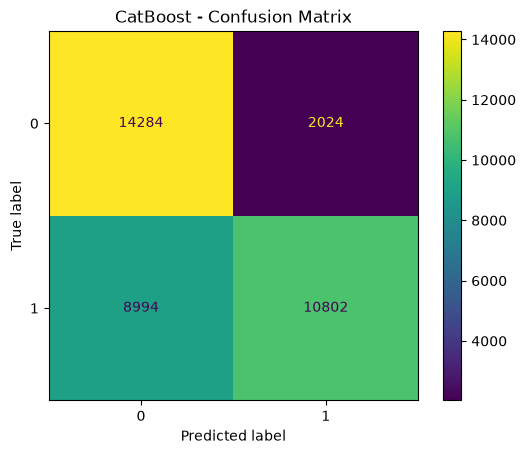


Final Test Evaluation: {'Model': 'CatBoost', 'Precision': 0.8421955403087479, 'Recall': 0.5456657910689028, 'F1': 0.6622524676598615, 'ROC-AUC': 0.7335242424656936}


In [13]:
# 10 اختيار أفضل موديل بناء على الـ Cross-Validation فقط (مش التست) - ده هيصلح ملاحظة 
best_model_name = df_cv_results['Mean ROC-AUC'].idxmax()
print(f"\nBest Model Selected from Cross-Validation: {best_model_name}")

final_late_model = pipelines[best_model_name]
final_late_model.fit(X_tr_l, y_tr_l)

# التقييم النهائي - مرة واحدة بس على التست، بعد ما الموديل والـ Hyperparameters اتثبتوا خالص
final_late_results = evaluate_model(best_model_name, final_late_model, X_te_l, y_te_l)
print("\nFinal Test Evaluation:", final_late_results)

# ==========================================
# Feature Importance / SHAP - موديل التأخير (Late Delivery)
# ==========================================

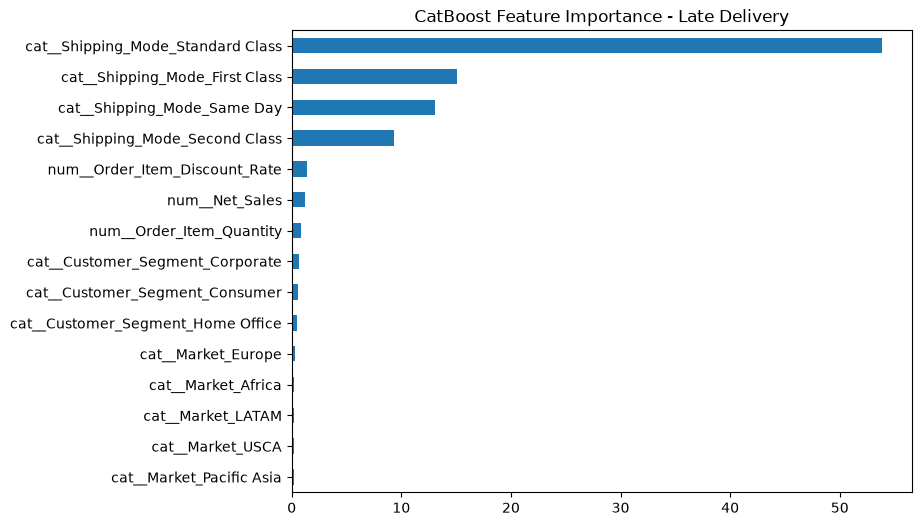

In [14]:
# 11 Feature Importance لموديل التأخير النهائي (حسب نوعه)
# دلوقتي الموديلات التلاتة كلها Pipeline (preprocessor + model)، فالمعاملة موحدة
model_step = final_late_model.named_steps['model']
feature_names = final_late_model.named_steps['preprocessor'].get_feature_names_out()

if hasattr(model_step, 'feature_importances_'):  # XGBoost أو CatBoost
    importance = pd.Series(model_step.feature_importances_, index=feature_names).sort_values(ascending=False)
    importance.head(15).plot(kind='barh', figsize=(8, 6), title=f'{best_model_name} Feature Importance - Late Delivery')
    plt.gca().invert_yaxis()
    plt.show()
else:  # Logistic Regression
    importance = pd.Series(np.abs(model_step.coef_[0]), index=feature_names).sort_values(ascending=False)
    importance.head(15).plot(kind='barh', figsize=(8, 6), title='Logistic Regression |Coefficients| - Late Delivery')
    plt.gca().invert_yaxis()
    plt.show()

# ==========================================
# نموذج 2: التنبؤ بالخسارة المالية (Negative Profit Risk)
# ==========================================

In [15]:
# 12 Features لموديل الخسارة
# تعديل الدكتورة: شيلنا Shipping_Delay_Days من هنا لأنه data leakage -
# الهدف هو "Predict financial loss BEFORE order delivery"، وShipping_Delay_Days
# (الفرق بين أيام الشحن الفعلية والمجدولة) مش هيكون معروف إلا بعد ما الشحن يحصل فعلا.
# سبناه في df فقط للاستخدام في الـ EDA، مش كـ feature هنا.
loss_features = [
    'Order_Item_Discount_Rate',
    'Order_Item_Discount',
    'Product_Price',
    'Order_Item_Quantity',
    'Category_Name',
    'Customer_Segment',
    'Market',
    'Shipping_Mode'
]

categorical_loss = ['Category_Name', 'Customer_Segment', 'Market', 'Shipping_Mode']

X_loss = df[loss_features]
y_loss = df['Is_Loss']

X_tr_loss, X_te_loss, y_tr_loss, y_te_loss = train_test_split(
    X_loss, y_loss, test_size=0.20, random_state=42, stratify=y_loss
)

negative_count = (y_tr_loss == 0).sum()
positive_count = (y_tr_loss == 1).sum()
scale_pos_weight = negative_count / positive_count

print("Scale Pos Weight:", scale_pos_weight)


Scale Pos Weight: 4.343360343360343


In [16]:
# 13 CatBoost Tuning لموديل الخسارة + Class Weighting (ده كان ناقص تماما قبل كده)
# نفس فكرة التعديل اللي عملناها في موديل التأخير: من غير cat_features في الـ constructor
# عشان نتجنب مشكلة sklearn's clone() RuntimeError - وبنستخدم preprocessor_loss (OneHotEncoder) بدالها
#
# تعديل الدكتورة: نفس مشكلة الـ threads bottleneck - CatBoost ياخد thread_count=-1
# والـ RandomizedSearchCV يشتغل n_jobs=1 (مش -1) عشان الـ Kernel ميقفش
preprocessor_loss = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical_loss)],
    remainder='passthrough'
)

cat_loss_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_loss),
    ('model', CatBoostClassifier(
        scale_pos_weight=float(scale_pos_weight),   # Scalar بدل List - بيتفادى مشكلة الـ clone()
        random_seed=42,
        verbose=0,
        thread_count=-1
    ))
])

cat_loss_params = {
    'model__iterations': [300, 500, 800],
    'model__depth': [4, 6, 8],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__l2_leaf_reg': [1, 3, 5, 7]
}

cat_loss_search = RandomizedSearchCV(
    estimator=cat_loss_pipeline,
    param_distributions=cat_loss_params,
    n_iter=8,          # قللتها من 15 لـ 8 عشان تسرّع الاختبار دلوقتي قبل التسليم
    scoring='roc_auc',
    cv=skf,
    random_state=42,
    n_jobs=1           # <-- تعديل الدكتورة: بدل -1: نمنع تعارض الـ threads مع CatBoost فعليًا
)

cat_loss_search.fit(X_tr_loss, y_tr_loss)
best_cat_loss = cat_loss_search.best_estimator_

print("Best CatBoost (Loss) Params:", cat_loss_search.best_params_)
print("Best CV ROC-AUC:", cat_loss_search.best_score_)


Best CatBoost (Loss) Params: {'model__learning_rate': 0.03, 'model__l2_leaf_reg': 1, 'model__iterations': 500, 'model__depth': 6}
Best CV ROC-AUC: 0.501605461973584


In [17]:
# 14 Cross-Validation موحدة لمقارنة موديلات الخسارة الثلاثة (على الـ Train فقط)
pipelines_loss = {
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor_loss),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor_loss),
        ('model', XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight))
    ]),
    'CatBoost': best_cat_loss
}

cv_results_loss = {}
for name, pipeline in pipelines_loss.items():
    scores = cross_validate(
        pipeline, X_tr_loss, y_tr_loss, cv=skf,
        scoring=['f1', 'roc_auc']
    )
    cv_results_loss[name] = {
        'Mean F1': scores['test_f1'].mean(),
        'Mean ROC-AUC': scores['test_roc_auc'].mean()
    }

df_cv_results_loss = pd.DataFrame(cv_results_loss).T
print("===== Loss Model Cross-Validation Results (Train Only) =====")
display(df_cv_results_loss)

===== Loss Model Cross-Validation Results (Train Only) =====


,Mean F1,Mean ROC-AUC
Random Forest,0.254520,0.499541
XGBoost,0.268125,0.503337
CatBoost,0.271906,0.501605


Best Loss Model: XGBoost | Mean CV ROC-AUC: 0.503
Is the Loss model reliable enough to use in the dashboard? False

===== XGBoost =====
              precision    recall  f1-score   support

           0       0.81      0.53      0.64     29347
           1       0.19      0.47      0.27      6757

    accuracy                           0.52     36104
   macro avg       0.50      0.50      0.45     36104
weighted avg       0.70      0.52      0.57     36104



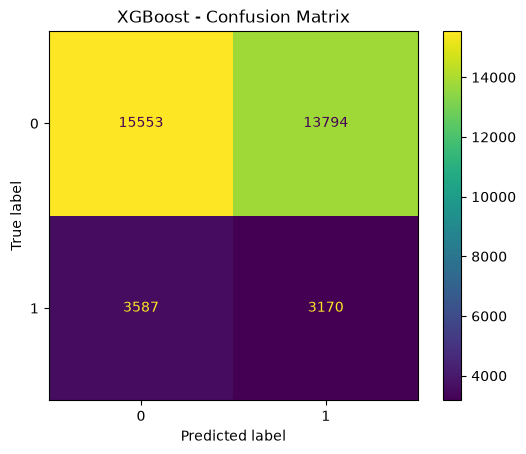


Final Test Evaluation: {'Model': 'XGBoost', 'Precision': 0.18686630511671776, 'Recall': 0.46914311084800947, 'F1': 0.2672737237047342, 'ROC-AUC': 0.5001653599788225}


In [18]:
# 15 اختيار أفضل موديل خسارة من الـ CV + قرار صريح: هل الموديل قوي كفاية يتستخدم في الداشبورد ولا لأ؟
best_loss_name = df_cv_results_loss['Mean ROC-AUC'].idxmax()
best_loss_auc = df_cv_results_loss.loc[best_loss_name, 'Mean ROC-AUC']

print(f"Best Loss Model: {best_loss_name} | Mean CV ROC-AUC: {best_loss_auc:.3f}")

# عتبة قرار: لو الموديل مفيهوش قوة تنبؤية حقيقية (قريب من 0.50) متستخدمهوش في التوصيات
USE_LOSS_MODEL = best_loss_auc > 0.60
print("Is the Loss model reliable enough to use in the dashboard?", USE_LOSS_MODEL)

final_loss_model = pipelines_loss[best_loss_name]
final_loss_model.fit(X_tr_loss, y_tr_loss)

# التقييم النهائي - مرة واحدة بس على التست
final_loss_results = evaluate_model(best_loss_name, final_loss_model, X_te_loss, y_te_loss)
print("\nFinal Test Evaluation:", final_loss_results)

# ==========================================
# Feature Importance - موديل الخسارة المالية (Loss)
# ==========================================

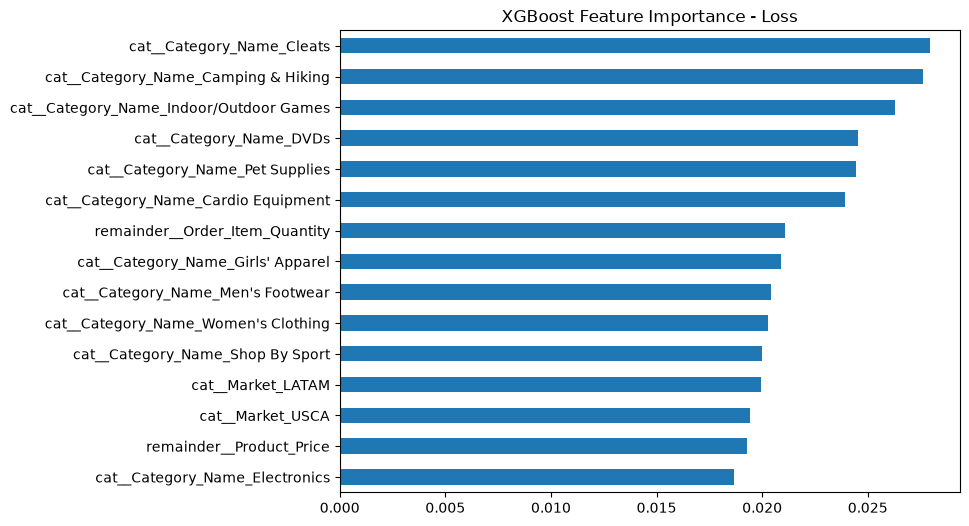

In [19]:
# 16 Feature Importance لموديل الخسارة النهائي - نفس المعاملة الموحدة (كلهم Pipeline دلوقتي)
model_step = final_loss_model.named_steps['model']
feature_names = final_loss_model.named_steps['preprocessor'].get_feature_names_out()
importance = pd.Series(model_step.feature_importances_, index=feature_names).sort_values(ascending=False)
importance.head(15).plot(kind='barh', figsize=(8, 6), title=f'{best_loss_name} Feature Importance - Loss')
plt.gca().invert_yaxis()
plt.show()

# ==========================================
#  K-Means Clustering (Scaling + Silhouette Score + K Choice)
# ==========================================

In [20]:
# ==========================================
# 17 K-Means Features
# ==========================================
cluster_features = df[
    ['Order_Item_Discount_Rate', 'Net_Sales', 'Days_for_shipping_real']
].copy()

cluster_features = cluster_features.fillna(0)

print("Cluster features:")
display(cluster_features.head())
print("\nShape:", cluster_features.shape)

Cluster features:


,Order_Item_Discount_Rate,Net_Sales,Days_for_shipping_real
0,0.20,239.98,2
1,0.03,193.99,3
2,0.09,227.50,3
3,0.17,107.89,3
4,0.18,40.98,5



Shape: (180519, 3)


In [21]:
# 17 - 1
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

print("Cluster scaling completed.")
print("Scaled shape:", cluster_scaled.shape)

Cluster scaling completed.
Scaled shape: (180519, 3)


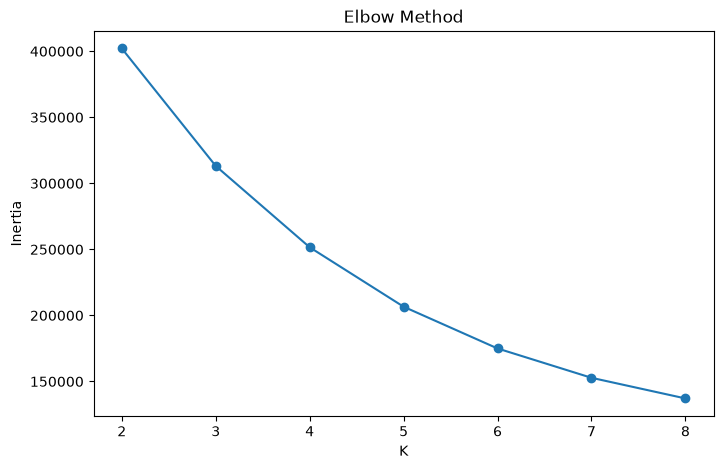

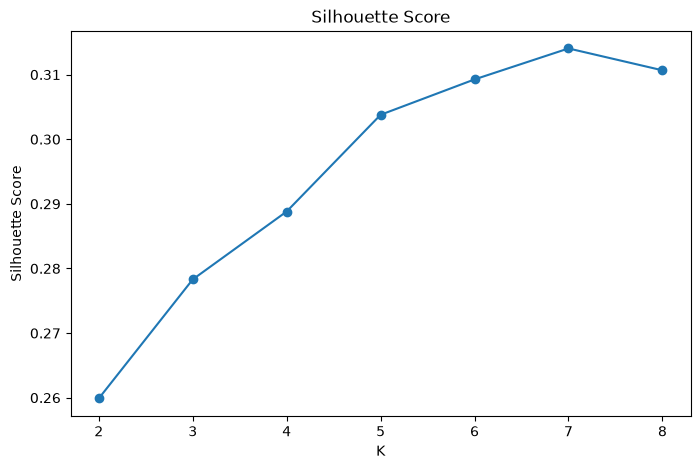

,K,Silhouette,Inertia
0,2,0.259890,402124.643013
1,3,0.278308,313156.884861
2,4,0.288819,251575.172134
3,5,0.303786,206575.826212
4,6,0.309260,174962.159521
5,7,0.314051,152754.217175
6,8,0.310667,137124.885488


In [22]:
# 17 - 2
k_values = range(2, 9)
inertia_values = []
silhouette_values = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(cluster_scaled)
    inertia_values.append(model.inertia_)

    sample_size = min(10000, len(cluster_scaled))
    rng = np.random.default_rng(42)
    sample_idx = rng.choice(len(cluster_scaled), sample_size, replace=False)

    score = silhouette_score(cluster_scaled[sample_idx], labels[sample_idx])
    silhouette_values.append(score)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertia_values, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), silhouette_values, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()

cluster_evaluation = pd.DataFrame({
    'K': list(k_values),
    'Silhouette': silhouette_values,
    'Inertia': inertia_values
})
display(cluster_evaluation)

In [23]:
# 17 - 3
best_k = cluster_evaluation.loc[cluster_evaluation['Silhouette'].idxmax(), 'K']
best_k = int(best_k)
print("Best K based on Silhouette Score:", best_k)

final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Risk_Cluster'] = final_kmeans.fit_predict(cluster_scaled)

Best K based on Silhouette Score: 7


In [24]:
# 18 (جديد) Cluster Profiling - بدل ما نسيب الكلاسترز أرقام من غير معنى
# تعديل الدكتورة: العمود ده فعليًا بيعد Order_Item_Id مش Order_Id، فسميناه Order_Item_Count
# بدل Order_Count عشان الاسم يبقى دقيق (لو عايزين عدد الـ Orders الفعلي نستخدم
# Order_Count=('Order_Id', 'nunique') بدالها)
cluster_profile = df.groupby('Risk_Cluster').agg(
    Avg_Discount_Rate=('Order_Item_Discount_Rate', 'mean'),
    Avg_Net_Sales=('Net_Sales', 'mean'),
    Avg_Shipping_Days=('Days_for_shipping_real', 'mean'),
    Order_Item_Count=('Order_Item_Id', 'count')
).round(2).reset_index()

display(cluster_profile)


,Risk_Cluster,Avg_Discount_Rate,Avg_Net_Sales,Avg_Shipping_Days,Order_Item_Count
0,0,0.05,133.57,2.15,37673
1,1,0.17,140.20,2.15,36436
2,2,0.17,139.56,5.00,32589
3,3,0.08,334.26,2.15,20781
4,4,0.05,132.42,5.00,33368
5,5,0.10,1351.65,3.62,467
6,6,0.08,331.70,5.00,19205


**ملحوظة:** بصي على جدول `cluster_profile` فوق، وسمي كل كلاستر باسم بيزنس مفهوم بناء على القيم
(مثال: كلاستر فيه Avg_Discount_Rate عالي وAvg_Shipping_Days عالي ممكن تسميه `High Discount - Slow Shipping`).
عدّلي الأسماء في القاموس اللي تحت بناء على الأرقام الفعلية اللي هتشوفيها.

In [25]:
# 19 (جديد) تسمية الكلاسترز بأسماء منطقية بدل الأرقام - عدّلي القيم دي بعد ما تشوفي cluster_profile
cluster_names = {
    cluster_id: f"Cluster_{cluster_id}_TODO_RENAME"
    for cluster_id in sorted(df['Risk_Cluster'].unique())
}

# مثال بعد المراجعة (لازم تتغير حسب أرقامك الحقيقية):
# تعديل الدكتورة: "Bulk" شالتها من اسم كلاستر 5 لأن الـ Quantity مش داخل في الـ clustering
# أصلا (features هي Discount Rate, Net Sales, Shipping Days بس)، فمفيش دليل إنه "Bulk" فعلا.
cluster_names = {
    0: 'Low Discount - Fast Shipping (Standard)',
    1: 'High Discount - Fast Shipping',
    2: 'High Discount - Slow Shipping (High Risk)',
    3: 'Mid-Value - Fast Shipping',
    4: 'Low Discount - Slow Shipping',
    5: 'High-Value Orders (Outlier Segment)',
    6: 'Mid-Value - Slow Shipping'
}

df['Cluster_Name'] = df['Risk_Cluster'].map(cluster_names)
display(df[['Risk_Cluster', 'Cluster_Name']].drop_duplicates())


,Risk_Cluster,Cluster_Name
0,1,High Discount - Fast Shipping
1,0,Low Discount - Fast Shipping (Standard)
2,3,Mid-Value - Fast Shipping
4,2,High Discount - Slow Shipping (High Risk)
5,6,Mid-Value - Slow Shipping
19,4,Low Discount - Slow Shipping
171764,5,High-Value Orders (Outlier Segment)


# ==========================================
# 20. تجهيز التنبؤات النهائية (Late Risk + Loss Risk) على كل الداتا
# ==========================================

In [26]:
# 20 Late Risk Probability - كل الموديلات دلوقتي بتاخد نفس الـ raw features (preprocessing جوه الـ Pipeline)
df['Late_Risk_Probability'] = final_late_model.predict_proba(df[late_features])[:, 1]

# Thresholds ديناميكية من الـ Validation (out-of-fold predictions) بدل الأرقام الثابتة 0.30/0.70
val_probs_late = cross_val_predict(final_late_model, X_tr_l, y_tr_l, cv=skf, method='predict_proba')[:, 1]

late_low_th = np.percentile(val_probs_late, 50)
late_high_th = np.percentile(val_probs_late, 80)
print(f"Late Delivery Thresholds -> Low/Medium: {late_low_th:.2f} | Medium/High: {late_high_th:.2f}")

df['Late_Risk_Level'] = pd.cut(
    df['Late_Risk_Probability'],
    bins=[-0.01, late_low_th, late_high_th, 1.00],
    labels=['Low', 'Medium', 'High']
)


Late Delivery Thresholds -> Low/Medium: 0.39 | Medium/High: 0.78


In [27]:
# 20-1 (جديد) تعديل الدكتورة: نتأكد إن الـ 50th/80th percentile thresholds فعلا بيفصلوا الـ risk كويس
# لازم Actual_Late_Rate تزيد بوضوح من Low لـ Medium لـ High - لو حصل كده يبقى الـ thresholds منطقية
# ونقدر نقول إن High Risk بيمثل تقريبا أعلى 20% من الأوردرات من حيث الاحتمالية المتوقعة
validation_risk = pd.DataFrame({
    'Actual_Late': y_tr_l.reset_index(drop=True),
    'Late_Probability': val_probs_late
})

validation_risk['Risk_Level'] = pd.cut(
    validation_risk['Late_Probability'],
    bins=[-0.01, late_low_th, late_high_th, 1.00],
    labels=['Low', 'Medium', 'High']
)

risk_validation_summary = (
    validation_risk
    .groupby('Risk_Level', observed=False)
    .agg(
        Orders=('Actual_Late', 'size'),
        Actual_Late_Orders=('Actual_Late', 'sum'),
        Actual_Late_Rate=('Actual_Late', 'mean'),
        Avg_Predicted_Probability=('Late_Probability', 'mean')
    )
    .reset_index()
)

risk_validation_summary['Actual_Late_Rate'] = risk_validation_summary['Actual_Late_Rate'] * 100
risk_validation_summary['Avg_Predicted_Probability'] = risk_validation_summary['Avg_Predicted_Probability'] * 100

display(risk_validation_summary)


,Risk_Level,Orders,Actual_Late_Orders,Actual_Late_Rate,Avg_Predicted_Probability
0,Low,72208,27386,37.926546,37.695217
1,Medium,43324,25359,58.533376,59.012547
2,High,28883,26436,91.527888,91.413970


In [28]:
# 21 Loss Risk - لو الموديل فعلا موثوق (USE_LOSS_MODEL=True) نستخدم الاحتمالية بتاعته
# لو لسه ضعيف، نستخدم قاعدة بيزنس بسيطة بدل ما نوهم الداشبورد بموديل مفهوش قوة تنبؤية
#
# تعديل الدكتورة: طالما الموديل ضعيف (ROC-AUC ~0.50) مينفعش نسمي ناتج الـ Business Rule
# "Loss_Risk_Level" كأنه prediction من ML. سميناه "Loss_Rule_Level" وضفنا عمود
# "Loss_Risk_Source" يوضح مصدر الرقم (ML Model أو Business Rule) عشان في الداشبورد
# والمناقشة يبقى واضح إن الموديل اتجرب واتعمله evaluation بس مكنش عنده predictive power
# كفاية، فمتعملش deployment له واستخدمنا Business Rule بدل منه.
if USE_LOSS_MODEL:
    df['Loss_Probability'] = final_loss_model.predict_proba(df[loss_features])[:, 1]

    val_probs_loss = cross_val_predict(final_loss_model, X_tr_loss, y_tr_loss, cv=skf, method='predict_proba')[:, 1]
    loss_low_th = np.percentile(val_probs_loss, 50)
    loss_high_th = np.percentile(val_probs_loss, 80)
    print(f"Loss Thresholds -> Low/Medium: {loss_low_th:.2f} | Medium/High: {loss_high_th:.2f}")

    df['Loss_Risk_Level'] = pd.cut(
        df['Loss_Probability'],
        bins=[-0.01, loss_low_th, loss_high_th, 1.00],
        labels=['Low', 'Medium', 'High']
    )
    df['Loss_Risk_Source'] = 'ML Model'

else:
    print("تنبيه: موديل الخسارة لسه مش قوي كفاية (ROC-AUC قريب من 0.50)."
          " هنستخدم قاعدة بيزنس (Business Rule) بدل الـ ML probability لحد ما يتحسن الموديل.")
    df['Loss_Probability'] = np.nan
    df['Loss_Rule_Level'] = np.where(
        (df['Order_Item_Discount_Rate'] > 0.15) & (df['Product_Price'] < df['Product_Price'].median()),
        'High', 'Low'
    )
    df['Loss_Risk_Source'] = 'Business Rule'

# نضمن إن العمودين موجودين دايما (حتى لو NaN) عشان التصدير للـ Dashboard يبقى ثابت الشكل
if 'Loss_Risk_Level' not in df.columns:
    df['Loss_Risk_Level'] = np.nan
if 'Loss_Rule_Level' not in df.columns:
    df['Loss_Rule_Level'] = np.nan

# عمود داخلي موحّد (مش هيتصدّر بالضرورة) بنستخدمه في منطق التوصيات (build_recommendation)
# بغض النظر عن مصدر الرقم - يشاور على أي عمود فعلا اتملى حسب USE_LOSS_MODEL
df['Loss_Risk_Level_Final'] = df['Loss_Risk_Level'] if USE_LOSS_MODEL else df['Loss_Rule_Level']


تنبيه: موديل الخسارة لسه مش قوي كفاية (ROC-AUC قريب من 0.50). هنستخدم قاعدة بيزنس (Business Rule) بدل الـ ML probability لحد ما يتحسن الموديل.


# ==========================================
#  التوصيات الذكية التلقائية (Smart Recommendations)
# ==========================================

In [29]:
# 22 Business Recommendations Rules - دلوقتي النص بيتطابق فعليا مع الشرط (Discount > 15%)
# تعديل الدكتورة: بنستخدم Loss_Risk_Level_Final هنا (مش Loss_Risk_Level مباشرة) عشان
# المنطق يشتغل صح سواء الرقم جاي من ML Model أو من Business Rule
def build_recommendation(row):
    high_discount = row['Order_Item_Discount_Rate'] > 0.15

    if row['Late_Risk_Level'] == 'High' and row['Loss_Risk_Level_Final'] == 'High':
        if high_discount:
            return 'Critical Alert: Re-evaluate Shipping Partner & Cap Discount at 15%'
        return 'Critical Alert: Re-evaluate Shipping Partner'

    elif row['Late_Risk_Level'] == 'High':
        return 'Logistics Warning: Priority Dispatch Required'

    elif row['Loss_Risk_Level_Final'] == 'High':
        if high_discount:
            return 'Financial Warning: Review Pricing (Discount Exceeds Safe Threshold 15%)'
        return 'Financial Warning: Review Pricing Strategy'

    else:
        return 'Optimal Order: Low Risk'

df['Recommendation'] = df.apply(build_recommendation, axis=1)

print("\nSample Output for Dashboard:")
display(df[[
    'Order_Item_Id', 'Late_Risk_Probability', 'Late_Risk_Level',
    'Loss_Probability', 'Loss_Risk_Level', 'Loss_Rule_Level', 'Loss_Risk_Source',
    'Risk_Cluster', 'Cluster_Name', 'Recommendation'
]].head())



Sample Output for Dashboard:


,Order_Item_Id,Late_Risk_Probability,Late_Risk_Level,Loss_Probability,Loss_Risk_Level,Loss_Rule_Level,Loss_Risk_Source,Risk_Cluster,Cluster_Name,Recommendation
0,1,0.396444,Medium,NaN,NaN,Low,Business Rule,1,High Discount - Fast Shipping,Optimal Order: Low Risk
1,2,0.389516,Low,NaN,NaN,Low,Business Rule,0,Low Discount - Fast Shipping (Standard),Optimal Order: Low Risk
2,3,0.373832,Low,NaN,NaN,Low,Business Rule,3,Mid-Value - Fast Shipping,Optimal Order: Low Risk
3,4,0.386172,Low,NaN,NaN,Low,Business Rule,1,High Discount - Fast Shipping,Optimal Order: Low Risk
4,5,0.374213,Low,NaN,NaN,High,Business Rule,2,High Discount - Slow Shipping (High Risk),Financial Warning: Review Pricing (Discount Ex...


# ==========================================
# تصدير النتائج بالكامل إلى SQL Server (Schema: gold)
# ==========================================

In [30]:
# 23 Final Data Integrity Check & SQL Export
print("Checking Data Integrity before Export:")
print("Nulls in Late Probability:", df['Late_Risk_Probability'].isnull().sum())
print("Nulls in Recommendation:", df['Recommendation'].isnull().sum())

# تعديل الدكتورة: بنصدّر Loss_Risk_Level و Loss_Rule_Level و Loss_Risk_Source كلهم بشكل منفصل
# عشان في الـ Power BI/الداشبورد يبقى واضح 100% أي قيمة جاية من ML Model وأي واحدة جاية من
# Business Rule، وميتلخبطش الاتنين ببعض
export_df = df[[
    'Order_Item_Id',
    'Late_Risk_Probability',
    'Late_Risk_Level',
    'Loss_Probability',
    'Loss_Risk_Level',
    'Loss_Rule_Level',
    'Loss_Risk_Source',
    'Risk_Cluster',
    'Cluster_Name',
    'Recommendation'
]].copy()

params = urllib.parse.quote_plus(conn_str)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

export_df.to_sql(
    name='Fact_AI_Predictions',
    schema='gold',
    con=engine,
    if_exists='replace',
    index=False
)

print("Successfully exported predictions to gold.Fact_AI_Predictions in SQL Server!")


Checking Data Integrity before Export:
Nulls in Late Probability: 0
Nulls in Recommendation: 0
Successfully exported predictions to gold.Fact_AI_Predictions in SQL Server!
